In [9]:
#image import for processing

from PIL import Image
import numpy as np
from IPython.display import display

def import_for_pillow(path):
    img = Image.open(path)

    print(f"   Format: {img.format}")
    print(f"   Size: {img.size}")  
    print(f"   Mode: {img.mode}")  

    if img.mode != 'RGB':
        img = img.convert('RGB')

    img_array = np.array(img)

    return img, img_array

pil_img, array = import_for_pillow("C:/Users/Amine/Documents/2026_projects/bees project/bees/samples_south/EAoR1r1m_ind07.dw.png")

   Format: PNG
   Size: (2048, 1536)
   Mode: RGB


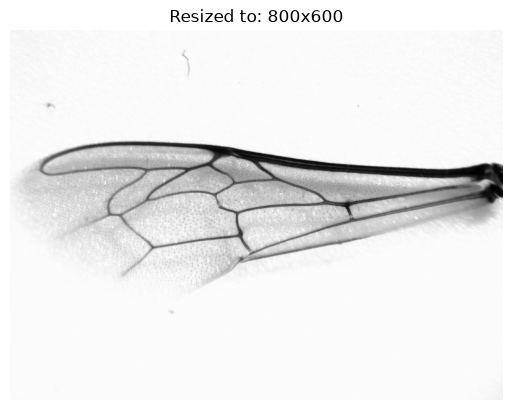

In [8]:
# Grayscaling and downsizing the image 

import cv2
import matplotlib.pyplot as plt

def smart_resize_grayscale(img, max_dimension=800):
    
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    height, width = gray.shape
    scale = min(max_dimension / height, max_dimension / width)
    
    new_width = int(width * scale)
    new_height = int(height * scale)

    resized = cv2.resize(gray, (new_width, new_height), interpolation=cv2.INTER_LANCZOS4)

    return resized

image_gray = smart_resize_grayscale(array, max_dimension=800)

plt.imshow(image_gray, cmap='gray')
plt.axis('off')
plt.title(f"Resized to: {image_gray.shape[1]}x{image_gray.shape[0]}")
plt.show()

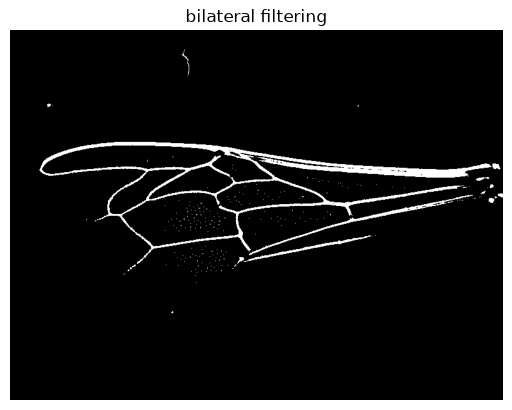

In [10]:
# generating binary image preparing for skeletonization

# bilateral = cv2.bilateralFilter(image_gray, d=30, sigmaColor=65, sigmaSpace=2.5)



blur1 = cv2.GaussianBlur(image_gray, (0, 0), sigmaX=5)
blur2 = cv2.GaussianBlur(image_gray, (0, 0), sigmaX=0.1)

dog = cv2.subtract(blur1, blur2)

dog_abs = cv2.convertScaleAbs(dog)

_, thresh = cv2.threshold(dog_abs, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)


plt.imshow(thresh, cmap='gray')
plt.axis('off')
plt.title("bilateral filtering")
plt.show()

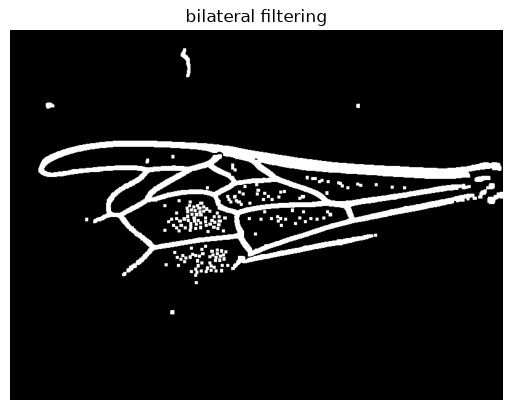

In [12]:
#dilation to deifne edges well

kernel = np.ones((5,5), np.uint8)

dilated_img = cv2.dilate(thresh, kernel, iterations=1)

plt.imshow(dilated_img, cmap='gray')
plt.axis('off')
plt.title("bilateral filtering")
plt.show()

C:\Users\Amine\AppData\Local\Temp\ipykernel_14188\1133923427.py:7: FutureWarning: `rectangle` is deprecated since version 0.25 and will be removed in version 0.27. Use `skimage.morphology.footprint_rectangle` instead.
  selem = morphology.rectangle(1, dilated_img.shape[1] // 10)


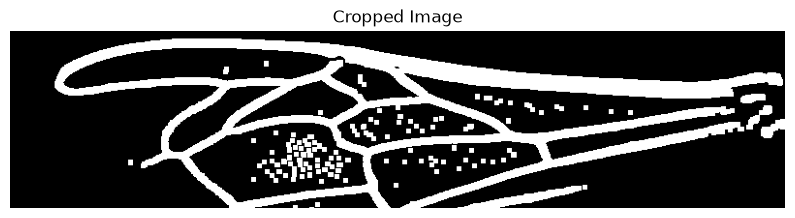

In [13]:
# auto cropping the image to focus on needed areas
from skimage import morphology
import numpy as np
import matplotlib.pyplot as plt

# Filter elements smaller than 1/6-th of the total width
selem = morphology.rectangle(1, dilated_img.shape[1] // 10)
img_opened = morphology.opening(dilated_img, selem)

hist = np.sum(img_opened, axis=1)
non_zero = np.where(hist > 0)[0]
top_bound = int(np.round(np.min(non_zero) * 0.95))
bottom_bound = int(np.round(np.max(non_zero) * 1.05))

# Crop the image
img_cropped = dilated_img[top_bound:bottom_bound, :]

# Display the cropped image
plt.figure(figsize=(10, 5))
plt.imshow(img_cropped, cmap='gray')
plt.title('Cropped Image')
plt.axis('off')
plt.show()

(np.float64(-0.5), np.float64(799.5), np.float64(182.5), np.float64(-0.5))

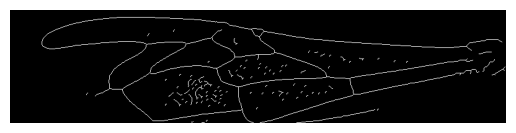

In [14]:
#skeletonizing the image 

from skimage.morphology import skeletonize

skeleton = skeletonize(img_cropped).astype(np.uint8) * 255

plt.imshow(skeleton, cmap='gray')
plt.axis('off')

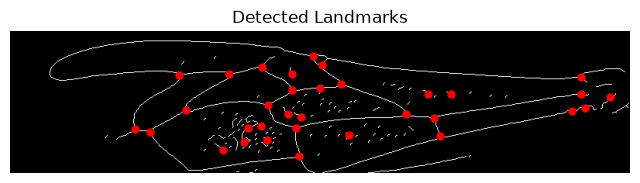

In [15]:
#detection of junction points

from skimage.morphology import skeletonize
from skimage.feature import corner_harris, corner_peaks

binary = (img_cropped > 0).astype(np.uint8)
skeleton = skeletonize(binary)

coords = corner_peaks(corner_harris(skeleton), min_distance=10, threshold_rel=0.3)

junction_points = []
for coord in coords:
    y, x = coord
    window = skeleton[y-3:y+4, x-3:x+4]
    if window.shape == (7, 7):
        transitions = 0
        for angle in range(0, 180, 30):
            pass 
    
    junction_points.append(coord)

plt.figure(figsize=(8, 8))
plt.imshow(skeleton, cmap='gray')
plt.plot([p[1] for p in junction_points], [p[0] for p in junction_points], 'ro', markersize=5)
plt.title('Detected Landmarks')
plt.axis('off')
plt.show()

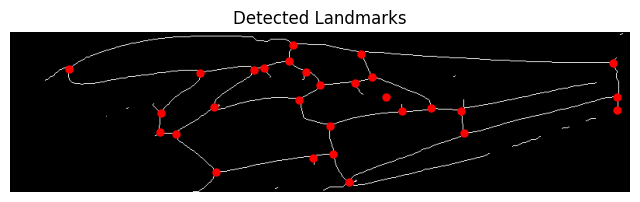

In [18]:
from functions import detect_junction_points
import matplotlib.pyplot as plt



image = "./bees/samples_north/MA-0125-TT01-000884-L.dw.png"
junction_points, intermediates  = detect_junction_points(
    image,
    max_dimension=800,
    min_distance=10,
    threshold_rel=0.3,
    return_intermediate=True,
)

skeleton1 = intermediates["skeleton"]

plt.figure(figsize=(8, 8))
plt.imshow(skeleton1, cmap='gray')
plt.plot([p[1] for p in junction_points], [p[0] for p in junction_points], 'ro', markersize=5)
plt.title('Detected Landmarks')
plt.axis('off')
plt.show()